## Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\Bharanidharan\Downloads\train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
for col in df.columns:
    if df[col].nunique() < 30:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())


Value counts for Survived:
Survived
0    549
1    342
Name: count, dtype: int64

Value counts for Pclass:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Value counts for Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Value counts for SibSp:
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

Value counts for Parch:
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

Value counts for Embarked:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


## Historgram

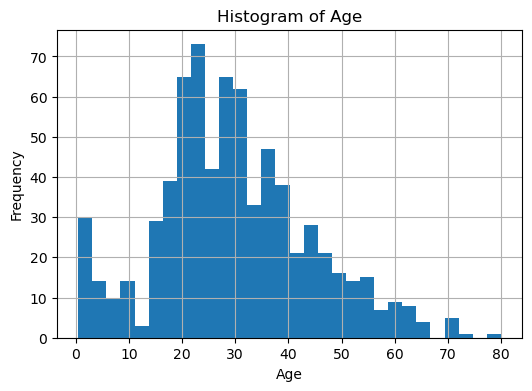

In [7]:
plt.figure(figsize=(6,4))
df['Age'].hist(bins=30)
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

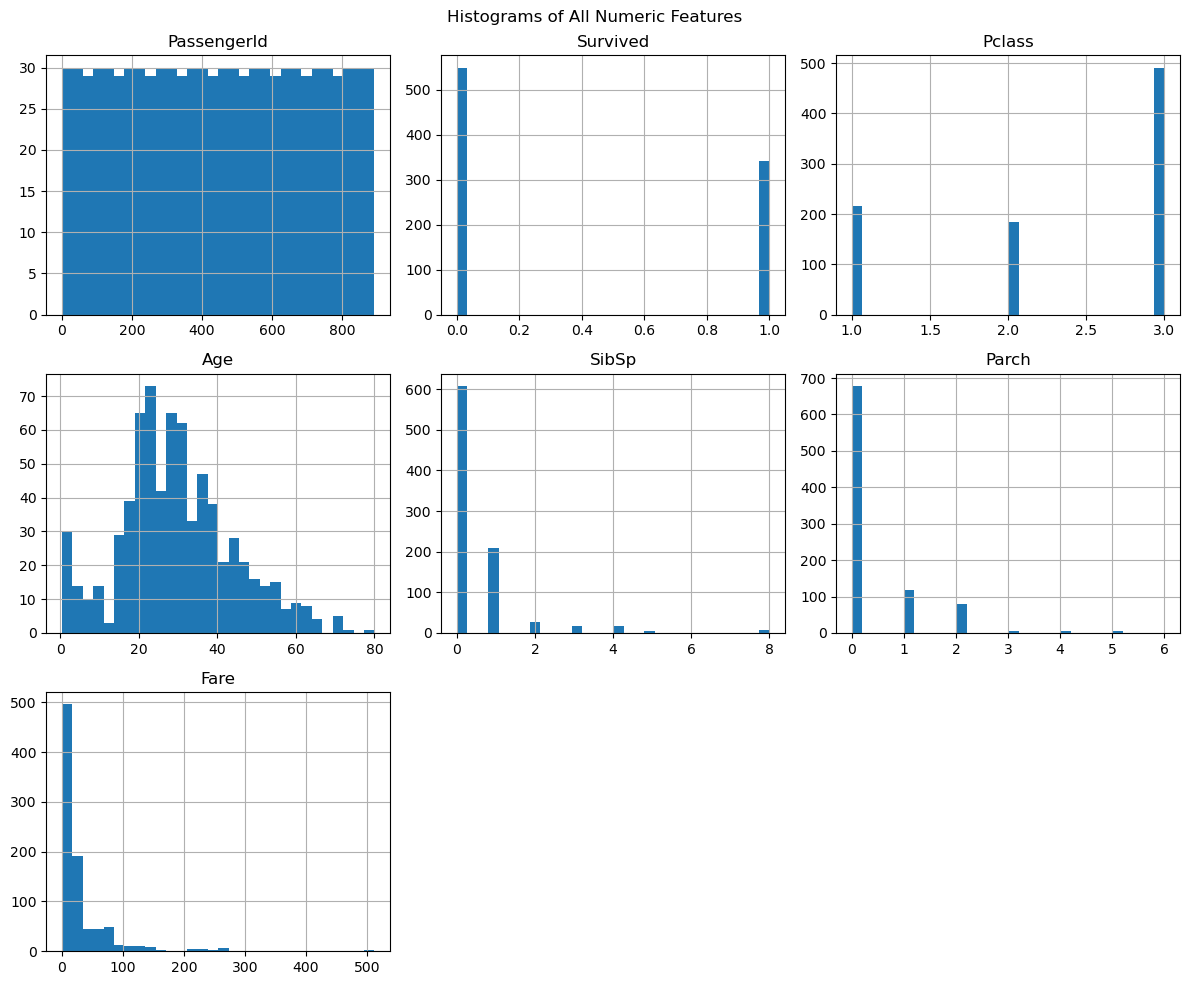

In [8]:
df.hist(bins=30, figsize=(12,10))
plt.suptitle('Histograms of All Numeric Features')
plt.tight_layout()
plt.show()


## Box_plots

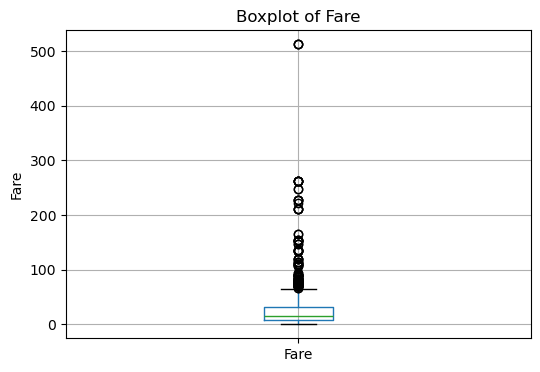

In [9]:
plt.figure(figsize=(6,4))
df.boxplot(column='Fare')
plt.title('Boxplot of Fare')
plt.ylabel('Fare')
plt.show()

## ScatterPlot

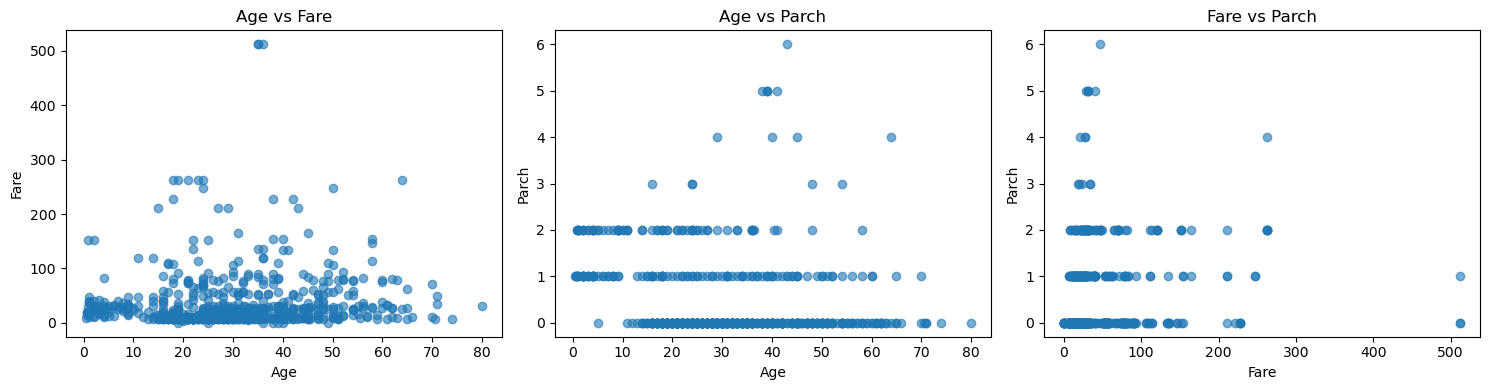

In [11]:
pairs = [('Age','Fare'), ('Age','Parch'), ('Fare','Parch')]
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (xcol, ycol) in zip(axes, pairs):
    ax.scatter(df[xcol], df[ycol], alpha=0.6)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f'{xcol} vs {ycol}')
plt.tight_layout()
plt.show()

In [12]:
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']
data = df[numeric_cols + ['Survived']] 

## PairPLot

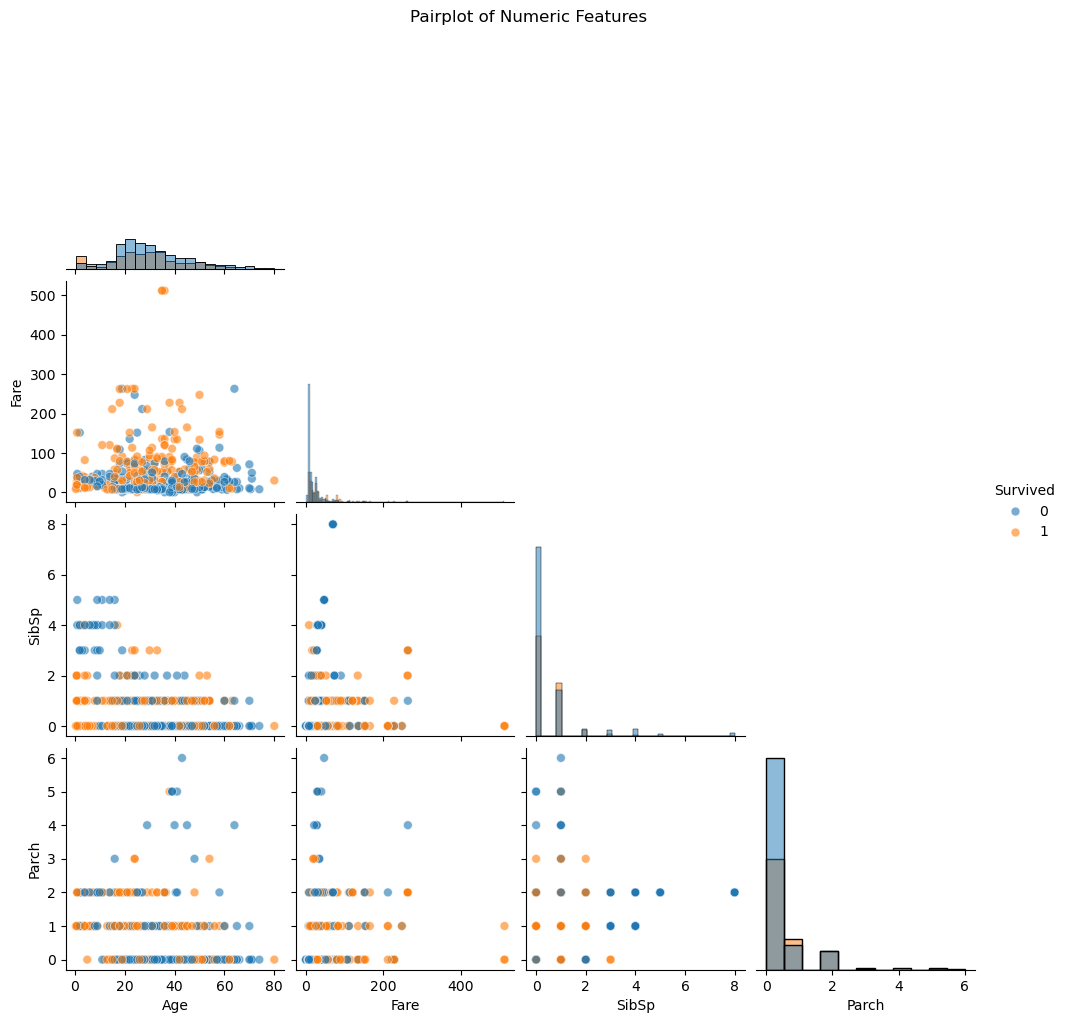

In [13]:
sns.pairplot(
    data,
    vars=numeric_cols,
    hue='Survived',
    diag_kind='hist',
    corner=True,       # only lower triangle
    plot_kws={'alpha':0.6, 's':40}
)
plt.suptitle('Pairplot of Numeric Features', y=1.02)
plt.show()

## heatmap

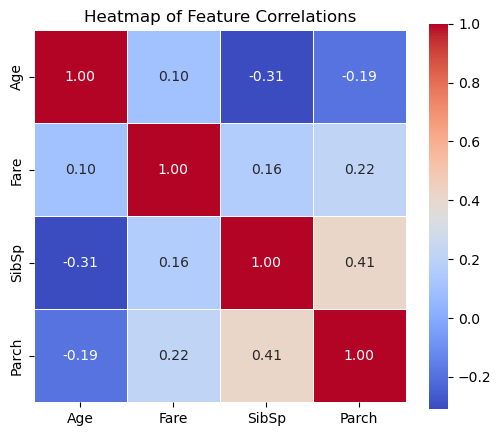

In [14]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    annot=True,        # show numbers in the squares
    fmt='.2f',         # 2 decimal places
    cmap='coolwarm',   # diverging color map
    square=True,
    linewidths=0.5
)
plt.title('Heatmap of Feature Correlations')
plt.show()

## Relationship and Trends

In [15]:
corr = df[['Survived','Pclass','Age','SibSp','Parch','Fare']].corr()

In [18]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [20]:
cols = ['Age', 'Fare', 'FamilySize', 'Survived']
plot_df = df[cols].dropna()

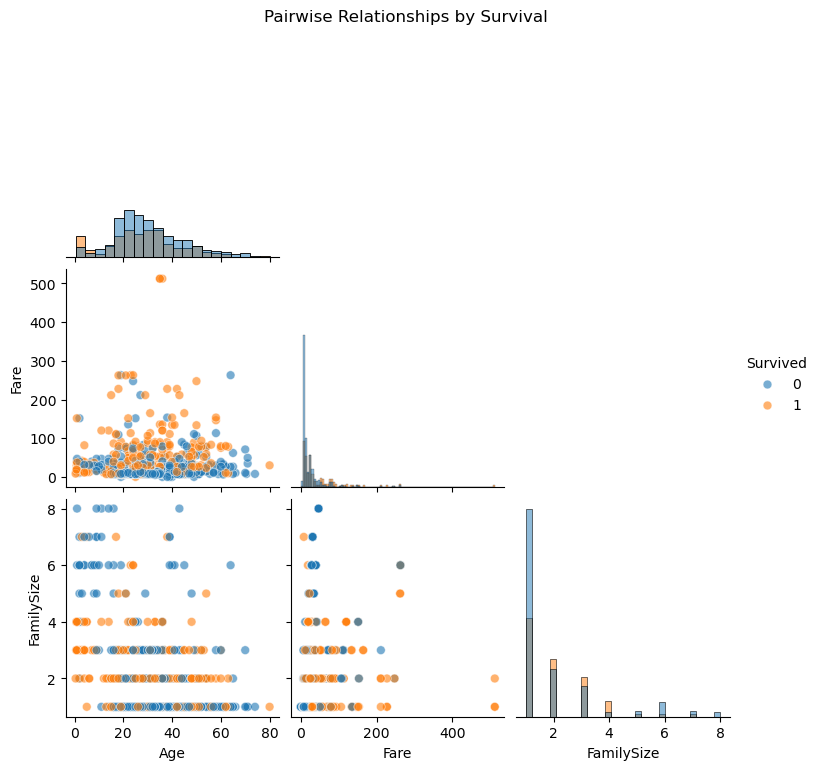

In [21]:
sns.pairplot(
    plot_df,
    vars=['Age', 'Fare', 'FamilySize'],
    hue='Survived',
    diag_kind='hist',
    corner=True,
    plot_kws={'alpha': 0.6, 's': 40}
)
plt.suptitle('Pairwise Relationships by Survival', y=1.02)
plt.show()

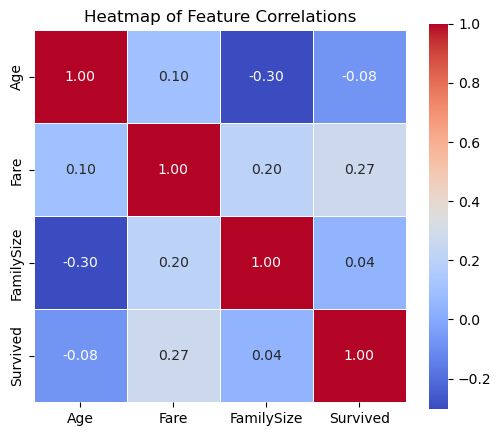

In [22]:
corr = plot_df[['Age', 'Fare', 'FamilySize', 'Survived']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5
)
plt.title('Heatmap of Feature Correlations')
plt.show()